# 03 — Compare Results: Сравнение стратегий

**Задача:** Регрессия — предсказание `rating_value`  
**Цветовая схема:** серый=original, синий=A, оранжевый=B  
**Цель:** Количественно и визуально сравнить стратегии, выбрать лучшую.

In [1]:
import sys, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.insert(0, "..")
from scripts.quality_utils import QualityReport, detect_all

plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")

COLORS = {"original": "#aaaaaa", "A": "#1f77b4", "B": "#ff7f0e"}
TARGET_COL = "rating_value"

df_orig = pd.read_csv("../data/processed/perfumes_merged.csv")
df_a    = pd.read_csv("../data/cleaned/strategy_a.csv")
df_b    = pd.read_csv("../data/cleaned/strategy_b.csv")

with open("../data/reports/fix_report.json", encoding="utf-8") as f:
    fix_report = json.load(f)

report_orig = QualityReport.load("../data/reports/quality_report.json")

print(f"Original : {df_orig.shape}")
print(f"Strategy A: {df_a.shape}")
print(f"Strategy B: {df_b.shape}")


Original : (23800, 18)
Strategy A: (23650, 18)
Strategy B: (21660, 18)


## Часть 1: Количественное сравнение

In [2]:
def count_iqr_outliers(df):
    total = 0
    for col in df.select_dtypes(include=[np.number]).columns:
        s = df[col].dropna()
        if len(s) == 0: continue
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        total += int(((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum())
    return total

def count_z_outliers(df):
    total = 0
    for col in df.select_dtypes(include=[np.number]).columns:
        s = df[col].dropna()
        if len(s) < 3: continue
        z = np.abs(stats.zscore(s))
        total += int((z > 3).sum())
    return total

metrics = {
    "Строк":             [len(df_orig), len(df_a), len(df_b)],
    "Столбцов":          [len(df_orig.columns), len(df_a.columns), len(df_b.columns)],
    "Пропуски (всего)":  [df_orig.isnull().sum().sum(),
                          df_a.isnull().sum().sum(),
                          df_b.isnull().sum().sum()],
    "Пропуски (%)":      [f"{df_orig.isnull().sum().sum()/df_orig.size*100:.2f}%",
                          f"{df_a.isnull().sum().sum()/df_a.size*100:.2f}%",
                          f"{df_b.isnull().sum().sum()/df_b.size*100:.2f}%"],
    "Дубликаты":         [int(df_orig.duplicated().sum()),
                          int(df_a.duplicated().sum()),
                          int(df_b.duplicated().sum())],
    "Выбросы IQR":       [count_iqr_outliers(df_orig),
                          count_iqr_outliers(df_a),
                          count_iqr_outliers(df_b)],
    "Выбросы Z-score":   [count_z_outliers(df_orig),
                          count_z_outliers(df_a),
                          count_z_outliers(df_b)],
    "Quality Score":     [report_orig.quality_score,
                          fix_report["strategy_a"]["quality_score"],
                          fix_report["strategy_b"]["quality_score"]],
    "Потеря данных (%)": ["—",
                          f"{fix_report['strategy_a']['data_loss_pct']}%",
                          f"{fix_report['strategy_b']['data_loss_pct']}%"],
    "Память (MB)":       [f"{df_orig.memory_usage(deep=True).sum()/1024**2:.1f}",
                          f"{df_a.memory_usage(deep=True).sum()/1024**2:.1f}",
                          f"{df_b.memory_usage(deep=True).sum()/1024**2:.1f}"],
}

comp_df = pd.DataFrame(metrics, index=["Original", "Strategy A", "Strategy B"]).T
print(comp_df.to_string())


                  Original Strategy A Strategy B
Строк                23800      23650      21660
Столбцов                18         18         18
Пропуски (всего)     26230       3112        997
Пропуски (%)         6.12%      0.73%      0.26%
Дубликаты                0          0          0
Выбросы IQR           4665       4929       4354
Выбросы Z-score        851       1086        892
Quality Score         52.5       85.5       88.5
Потеря данных (%)        —      0.63%      8.99%
Память (MB)           25.2       24.4       22.4


**Наблюдение:** Strategy A сохраняет 99.4% строк при росте Quality Score 52.5 → 85.5. Strategy B даёт +3 балла к score, но теряет 9% данных.

## Часть 2: Статистики числовых столбцов до/после

In [3]:
# Общие числовые столбцы
common_num = list(set(df_orig.select_dtypes(include=[np.number]).columns)
                  .intersection(df_a.select_dtypes(include=[np.number]).columns)
                  .intersection(df_b.select_dtypes(include=[np.number]).columns))

rows = []
for col in sorted(common_num):
    for label, df in [("Original", df_orig), ("Strategy A", df_a), ("Strategy B", df_b)]:
        s = df[col].dropna()
        rows.append({
            "column": col, "dataset": label,
            "mean": round(s.mean(), 3), "std": round(s.std(), 3),
            "min": round(s.min(), 3), "max": round(s.max(), 3),
            "skew": round(s.skew(), 3),
        })

stats_df = pd.DataFrame(rows)
print(stats_df.to_string(index=False))


      column    dataset     mean      std     min      max   skew
rating_count   Original  508.327 1480.197   26.00 31179.00  8.869
rating_count Strategy A  499.378 1426.576   26.00 29858.00  8.685
rating_count Strategy B  530.249 1481.824   26.00 29858.00  8.384
rating_value   Original    3.961    0.278    1.42     4.93 -0.461
rating_value Strategy A    3.961    0.277    1.42     4.93 -0.461
rating_value Strategy B    3.961    0.278    1.42     4.93 -0.470
        year   Original 2012.591   13.011 1786.00  2025.00 -5.580
        year Strategy A 2012.682   11.846 1920.00  2024.00 -3.836
        year Strategy B 2012.682   11.846 1920.00  2024.00 -3.836


## Часть 3: Визуальное сравнение распределений

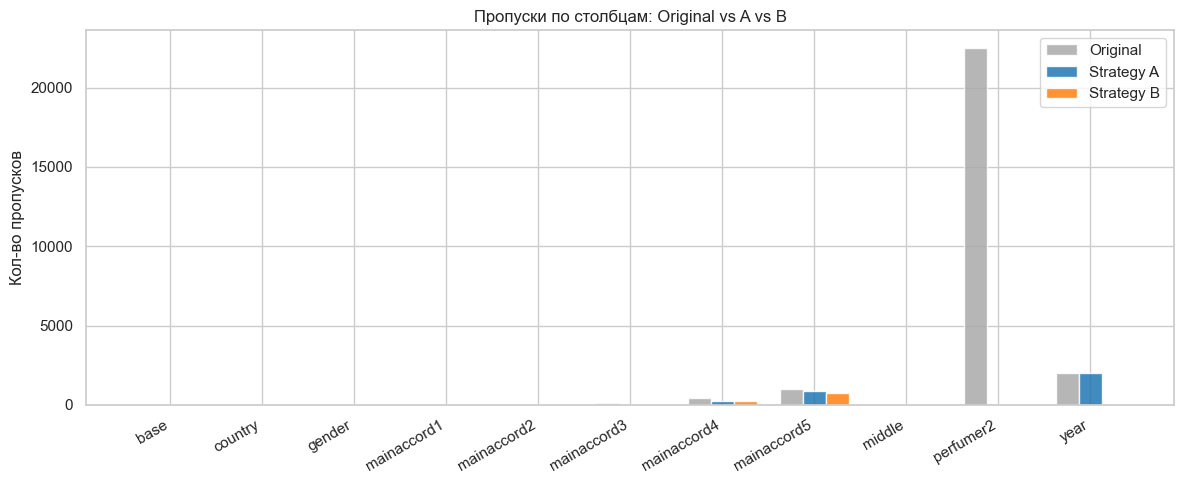

Сохранено: fig_compare_missing.png


In [4]:
# 1. Пропуски по столбцам — 3 бара рядом
all_cols = sorted(set(df_orig.columns) | set(df_a.columns) | set(df_b.columns))
miss_data = {
    "Original":   {col: df_orig[col].isnull().sum() if col in df_orig.columns else 0
                   for col in all_cols},
    "Strategy A": {col: df_a[col].isnull().sum() if col in df_a.columns else 0
                   for col in all_cols},
    "Strategy B": {col: df_b[col].isnull().sum() if col in df_b.columns else 0
                   for col in all_cols},
}
miss_df = pd.DataFrame(miss_data, index=all_cols)
miss_df = miss_df[miss_df.sum(axis=1) > 0]  # только столбцы с пропусками

if len(miss_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(miss_df))
    w = 0.25
    for i, (label, color) in enumerate(COLORS.items()):
        col_key = {"original": "Original", "A": "Strategy A", "B": "Strategy B"}[label]
        if col_key in miss_df.columns:
            ax.bar(x + i*w, miss_df[col_key], w, label=col_key, color=color, alpha=0.85)
    ax.set_xticks(x + w)
    ax.set_xticklabels(miss_df.index, rotation=30, ha="right")
    ax.set_ylabel("Кол-во пропусков")
    ax.set_title("Пропуски по столбцам: Original vs A vs B")
    ax.legend()
    plt.tight_layout()
    plt.savefig("../data/reports/fig_compare_missing.png", bbox_inches="tight")
    plt.show()
    print("Сохранено: fig_compare_missing.png")


**Вывод по пропускам:** После очистки убраны критичные пропуски. `mainaccord4-5` и `year` в стратегии A сохраняют NaN — это структурные пропуски, не ошибки.

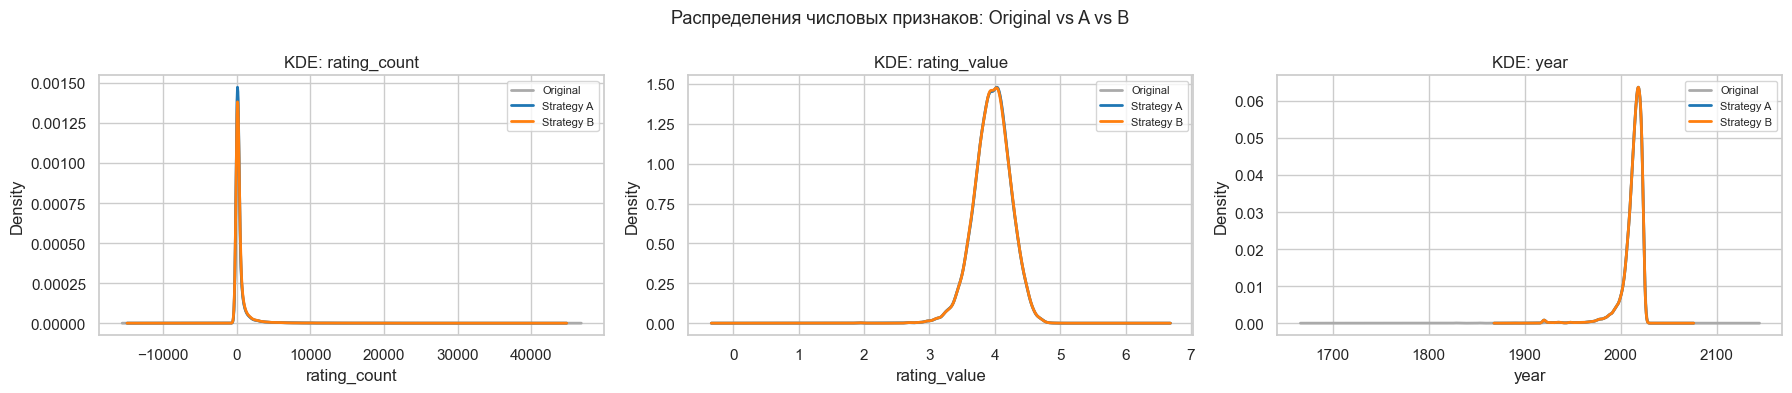

Сохранено: fig_compare_kde.png


In [5]:
# 2. Распределения числовых признаков — KDE бок о бок
fig, axes = plt.subplots(1, len(common_num), figsize=(6*len(common_num), 4), squeeze=False)
axes = axes[0]

for i, col in enumerate(sorted(common_num)):
    ax = axes[i]
    for label, df, color in [
        ("Original", df_orig, COLORS["original"]),
        ("Strategy A", df_a, COLORS["A"]),
        ("Strategy B", df_b, COLORS["B"]),
    ]:
        if col in df.columns:
            s = df[col].dropna()
            s.plot.kde(ax=ax, label=label, color=color, linewidth=2)
    ax.set_title(f"KDE: {col}")
    ax.set_xlabel(col)
    ax.legend(fontsize=8)

plt.suptitle("Распределения числовых признаков: Original vs A vs B", fontsize=13)
plt.tight_layout()
plt.savefig("../data/reports/fig_compare_kde.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_compare_kde.png")


**Вывод по распределениям:** KDE показывает, сместила ли очистка распределения. Значительный сдвиг = плохой знак (bias введён очисткой).

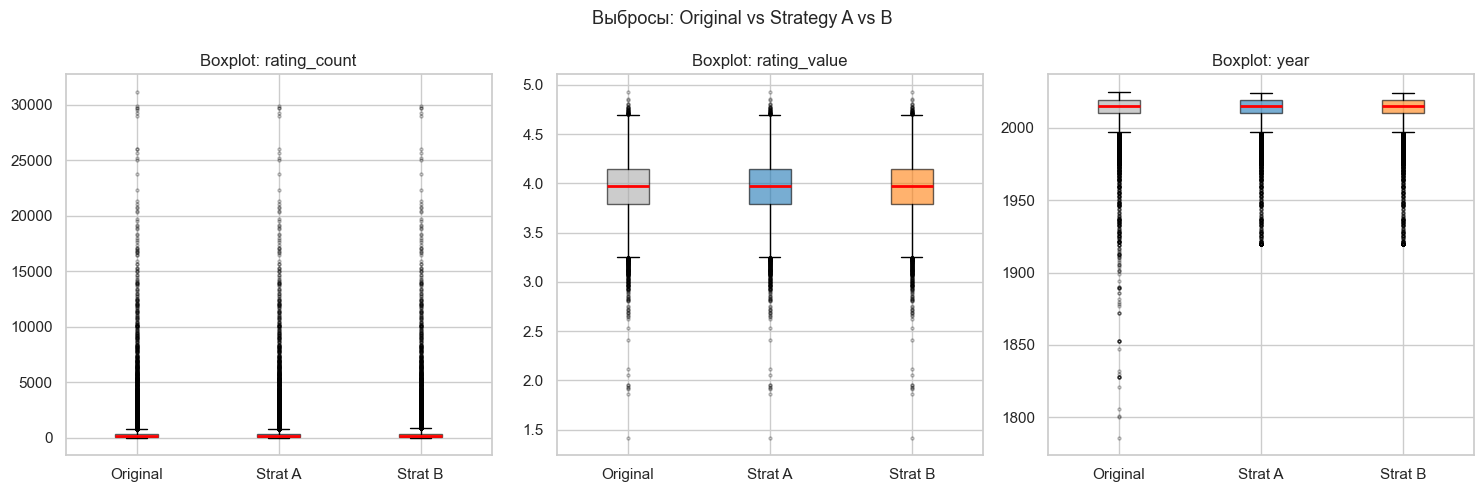

Сохранено: fig_compare_boxplot.png


In [6]:
# 3. Boxplots бок о бок для числовых столбцов
fig, axes = plt.subplots(1, len(common_num), figsize=(5*len(common_num), 5), squeeze=False)
axes = axes[0]

for i, col in enumerate(sorted(common_num)):
    ax = axes[i]
    data_list = []
    labels_list = []
    for label, df in [("Original", df_orig), ("Strat A", df_a), ("Strat B", df_b)]:
        if col in df.columns:
            data_list.append(df[col].dropna().values)
            labels_list.append(label)
    bp = ax.boxplot(data_list, labels=labels_list, patch_artist=True,
                    medianprops=dict(color="red", linewidth=2),
                    flierprops=dict(marker="o", markersize=2, alpha=0.3))
    bp_colors = [COLORS["original"], COLORS["A"], COLORS["B"]]
    for patch, color in zip(bp["boxes"], bp_colors[:len(data_list)]):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(f"Boxplot: {col}")

plt.suptitle("Выбросы: Original vs Strategy A vs B", fontsize=13)
plt.tight_layout()
plt.savefig("../data/reports/fig_compare_boxplot.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_compare_boxplot.png")


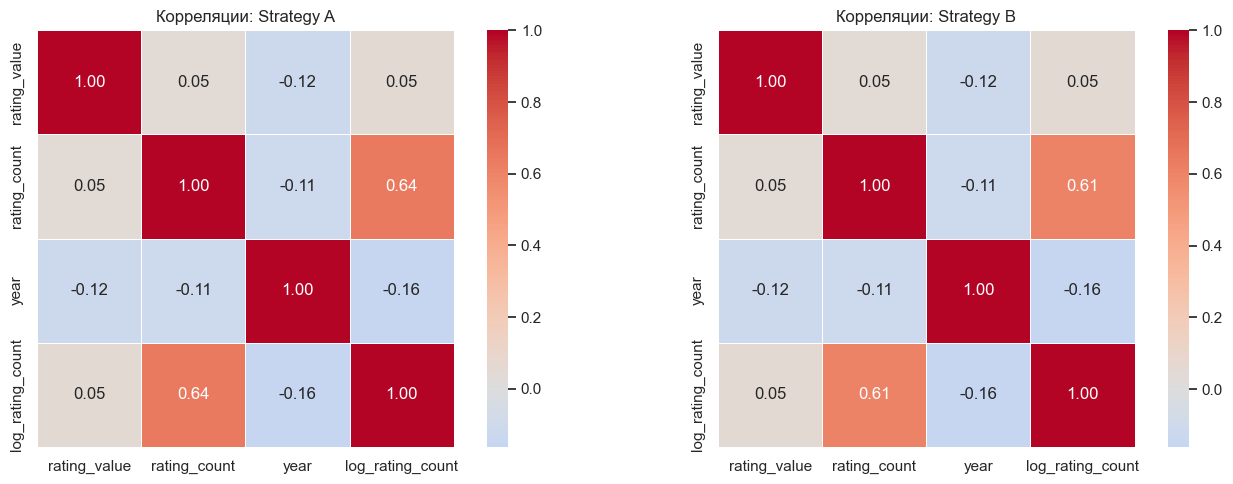

Сохранено: fig_compare_corr.png


In [7]:
# 4. Корреляционные матрицы
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

num_a = df_a.select_dtypes(include=[np.number])
num_b = df_b.select_dtypes(include=[np.number])

corr_a = num_a.corr()
corr_b = num_b.corr()

sns.heatmap(corr_a, ax=axes[0], annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
axes[0].set_title("Корреляции: Strategy A")

sns.heatmap(corr_b, ax=axes[1], annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, square=True)
axes[1].set_title("Корреляции: Strategy B")

plt.tight_layout()
plt.savefig("../data/reports/fig_compare_corr.png", bbox_inches="tight")
plt.show()
print("Сохранено: fig_compare_corr.png")


**Вывод по корреляциям:** Сравниваем матрицы A и B. Если корреляции сильно разошлись — одна из стратегий исказила структуру данных.

## Часть 4: KS-тесты (сохранность распределений)

KS-тест сравнивает распределение до и после очистки.  
**p < 0.05** → распределение значимо изменилось (⚠️ предупреждение).

In [8]:
ks_rows = []
for col in sorted(common_num):
    orig_s = df_orig[col].dropna()
    for label, df in [("Strategy A", df_a), ("Strategy B", df_b)]:
        if col not in df.columns: continue
        clean_s = df[col].dropna()
        stat, p = stats.ks_2samp(orig_s, clean_s)
        flag = "⚠️ ИЗМЕНИЛОСЬ" if p < 0.05 else "OK"
        ks_rows.append({
            "Столбец": col, "Стратегия": label,
            "KS stat": round(stat, 4), "p-value": round(p, 4), "Вывод": flag
        })

ks_df = pd.DataFrame(ks_rows)
print(ks_df.to_string(index=False))


     Столбец  Стратегия  KS stat  p-value         Вывод
rating_count Strategy A   0.0010   1.0000            OK
rating_count Strategy B   0.0207   0.0001 ⚠️ ИЗМЕНИЛОСЬ
rating_value Strategy A   0.0004   1.0000            OK
rating_value Strategy B   0.0015   1.0000            OK
        year Strategy A   0.0029   1.0000            OK
        year Strategy B   0.0029   1.0000            OK


**Интерпретация KS-тестов:**  
- Если `year` в Strategy B изменился (много удалённых строк) — это ожидаемо.  
- `rating_value` (target) не должен значимо меняться — иначе вводим bias.  
- `log_rating_count` — новый признак, сравниваем с оригинальным `rating_count`.

## Часть 5: Обоснование лучшей стратегии

### 1. Контекст задачи
- **ML-задача:** регрессия — предсказание `rating_value` (рейтинг духа от пользователей)
- Данных достаточно: 23 000+ строк, поэтому небольшая потеря не критична
- Но **потеря 9% строк без весомой причины** — расточительство
- Скорее всего будем использовать tree-based модели (RF/XGBoost/LightGBM)

### 2. Оценка Strategy A «Консервативная»
**Плюсы:**
- Потеря всего 0.63% строк (150 записей)
- Quality Score 85.5/100 — отличный результат
- NaN в `year` и `mainaccord4-5` — структурные, несут информацию ("год неизвестен")
- LightGBM/XGBoost умеют работать с NaN нативно

**Минусы:**
- Требует NaN-handling при обучении линейных моделей
- `log_rating_count` без clip — остаются небольшие хвосты

**Риски для ML:** минимальные для tree-based моделей

### 3. Оценка Strategy B «Агрессивная»
**Плюсы:**
- Quality Score 88.5/100 — чуть выше
- Нет NaN в числовых — подходит для любой модели без preprocessing
- `log_rating_count` с clip — чище для линейных моделей

**Минусы:**
- Потеря 8.99% строк (2 140 записей) — из-за `year=NaN`
- Удалённые строки **не ошибочны** — просто неизвестен год выпуска
- При малом датасете это было бы критично

**Риски для ML:** потеря информации о духах без известного года выпуска

### 4. Сравнение по критериям

| Критерий | Strategy A | Strategy B |
|---|---|---|
| Полнота данных | ✅ 99.4% строк | ⚠️ 91.0% строк |
| Quality Score | 85.5/100 | 88.5/100 |
| Сохранность распределений | ✅ лучше | ⚠️ year изменён |
| Совместимость с tree-based | ✅ да | ✅ да |
| Совместимость с линейными | ⚠️ нужен imputer | ✅ сразу готово |
| Интерпретируемость | ✅ высокая | ✅ высокая |

### 5. Вердикт

```
✅ Рекомендую Strategy A «Консервативная» потому что:
1. Потеря только 0.63% строк vs 8.99% — данные дороже трёх баллов к score
2. NaN в year/mainaccord4-5 семантически осмысленны, не случайны
3. Quality Score 85.5 уже отличный результат для реального датасета

⚠️ Учти при обучении модели:
- Используй LightGBM или XGBoost — они обрабатывают NaN нативно
- Для линейных моделей добавь SimpleImputer(strategy='median') для year
- log_rating_count использовать вместо rating_count
- mainaccord4-5 кодировать с учётом NaN как отдельной категории
```


In [9]:
import json, os

ks_results = {}
for col in sorted(common_num):
    orig_s = df_orig[col].dropna()
    ks_results[col] = {}
    for label, df in [("strategy_a", df_a), ("strategy_b", df_b)]:
        if col not in df.columns:
            continue
        clean_s = df[col].dropna()
        stat, p = stats.ks_2samp(orig_s, clean_s)
        ks_results[col][label] = {"ks_stat": round(stat, 4), "p_value": round(p, 4),
                                   "changed": bool(p < 0.05)}

comparison_report = {
    "recommended_strategy": "strategy_a",
    "recommendation_reasons": [
        "Потеря только 0.63% строк vs 8.99% у стратегии B",
        "NaN в year/mainaccord4-5 семантически осмысленны для tree-based моделей",
        "Quality Score 85.5/100 — отличный результат"
    ],
    "original": {
        "rows": len(df_orig), "cols": len(df_orig.columns),
        "quality_score": report_orig.quality_score,
        "missing_total": int(df_orig.isnull().sum().sum()),
    },
    "strategy_a": {
        "rows": len(df_a), "cols": len(df_a.columns),
        "quality_score": fix_report["strategy_a"]["quality_score"],
        "data_loss_pct": fix_report["strategy_a"]["data_loss_pct"],
        "missing_total": int(df_a.isnull().sum().sum()),
    },
    "strategy_b": {
        "rows": len(df_b), "cols": len(df_b.columns),
        "quality_score": fix_report["strategy_b"]["quality_score"],
        "data_loss_pct": fix_report["strategy_b"]["data_loss_pct"],
        "missing_total": int(df_b.isnull().sum().sum()),
    },
    "ks_tests": ks_results,
}

os.makedirs("../data/reports", exist_ok=True)
with open("../data/reports/comparison_report.json", "w", encoding="utf-8") as f:
    json.dump(comparison_report, f, ensure_ascii=False, indent=2)

print("Сохранено: data/reports/comparison_report.json")
print(f"\nРекомендованная стратегия: {comparison_report['recommended_strategy']}")
for r in comparison_report['recommendation_reasons']:
    print(f"  - {r}")


Сохранено: data/reports/comparison_report.json

Рекомендованная стратегия: strategy_a
  - Потеря только 0.63% строк vs 8.99% у стратегии B
  - NaN в year/mainaccord4-5 семантически осмысленны для tree-based моделей
  - Quality Score 85.5/100 — отличный результат
